# langgraph

In [1]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage
from typing import TypedDict,List, Annotated
from operator import add
from langchain_core.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.messages import HumanMessage, ToolMessage
from typing import Literal
from typing import List, TypedDict
from concurrent.futures import ThreadPoolExecutor
from typing import List, TypedDict, Literal
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal, Optional, TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt


c:\Users\mnijh\Documents\GitHub\LangGraph_Full_Course\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()
hf_token = (
    os.getenv("HUGGINGFACEHUB_API_TOKEN")
    or os.getenv("HF_TOKEN")
    or os.getenv("HUGGINGFACE_API_KEY")
)

if not hf_token:
    raise ValueError(
        "Set HUGGINGFACEHUB_API_TOKEN (or HF_TOKEN/HUGGINGFACE_API_KEY) in your environment."
    )

# Make ChatOpenAI-compatible clients use Hugging Face Inference Router
os.environ["OPENAI_API_KEY"] = hf_token
os.environ["OPENAI_BASE_URL"] = "https://router.huggingface.co/v1"

In [9]:
llm = ChatOpenAI(model="Qwen/Qwen2.5-72B-Instruct")
llm.invoke("I want to know the meaning of water").content


'The term "water" refers to a chemical substance that is composed of hydrogen and oxygen atoms, with the chemical formula H2O. It is one of the most abundant and essential substances on Earth, playing a crucial role in the survival of all known forms of life. Here are some key points about water:\n\n1. **Chemical Properties**:\n   - Water is a polar molecule, which means it has a slightly positive charge on one end and a slightly negative charge on the other.\n   - It has a high specific heat capacity, which allows it to absorb and release large amounts of heat without significant changes in temperature.\n   - Water has a high surface tension, which is why it can form droplets and support light objects on its surface.\n\n2. **Physical States**:\n   - Water can exist in three states: solid (ice), liquid (water), and gas (water vapor or steam).\n\n3. **Biological Importance**:\n   - Water is essential for the functioning of cells and organisms. It is a solvent that helps transport nutrie

# **first graph**

### **step-1: define the schema**

In [10]:
class graph_schema(TypedDict):
    name : str
    message : str


### **step-2: create the node functions**

In [11]:
def welcome(schema:graph_schema) -> graph_schema:

    curr_name = schema['name']
    curr_message = schema['message']

    response = llm.invoke(f"My name is {curr_name}. {curr_message}").content

    schema['message'] = f"Your message was {curr_message}. Here's my response:  {response}"

    return schema


### **step-3: create the state graph**

In [12]:
graph = StateGraph(graph_schema)

# Adding Nodes
graph.add_node("welcome", welcome)

# Adding Edges
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)


### **step-4 compile the graph**


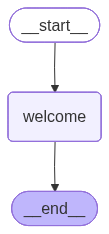

In [ ]:
first_graph = graph.compile()
Image(first_graph.get_graph().draw_mermaid_png())


### **step-5: run the graph**

In [ ]:
first_graph.invoke({"name":"Michiel","message":"How are you?"})

### **pydantic schema**

In [ ]:
class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the graph")
    post: str = Field(description="The post content")
    curated_post: str = Field(description="The curated post content")


demo_obj = graph_schema(
    topic="How do you use a neural network",
    post="Neural networks are a subset of machine learning algorithms that are designed to recognize patterns. They interpret sensory data through a kind of machine perception, labeling, or clustering of raw input.",
    curated_post="Neural networks are powerful tools in machine learning, capable of recognizing complex patterns in data."
)
print(demo_obj)


topic='The importance of data privacy in the digital age' post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy." curated_post='In the digital age, data privacy is more important than ever. With the'


In [ ]:
def create_post(state: graph_schema) -> graph_schema:
    
    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a post
    post = llm.invoke(f"Write a post about {topic}").content

    # Update the state with the generated post
    state['post'] = post

    return state


def curate_post(state: graph_schema) -> graph_schema:

    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Extract the post from the state
    post = state['post']

    # Passing the post to the LLM to curate it
    curated_post = llm.invoke(f"Curate the following post with GenZ tone: {post}").content


    # Update the state with the curated post
    state['curated_post'] = curated_post

    return state


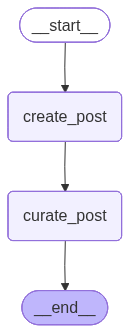

In [18]:
graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()




# You could see the errors with the below command
Image(pydantic_graph.get_graph().draw_mermaid_png())


In [ ]:
pydantic_graph.invoke(
    {"topic": "How do you use a neural network",
     "post": "",
     "curated_post": ""}
)


Messages

In [19]:
class graph_schema(TypedDict):

    messages_manual: List
    #Using Reducer in Langgraph
    messages_auto: Annotated[List,add]


In [20]:
def create_post(state: graph_schema) -> graph_schema:

    messages_manual = state['messages_manual']
    response_manual = llm.invoke(messages_manual).content 
    response__manual_ai = AIMessage(content=response_manual)
    state['messages_manual'] = messages_manual + [response__manual_ai]

    messages_auto = state['messages_auto']
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto'] = [response_auto_ai]

    return state


def curate_post(state: graph_schema) -> graph_schema:


    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    response__manual_ai = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [response__manual_ai]

    messages_auto = state['messages_auto']
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto'] = [response_auto_ai]


    return state


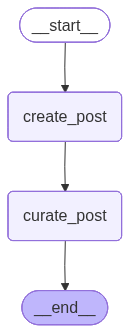

In [21]:
graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

messages_graph = graph.compile()




# You could see the errors with the below command
Image(messages_graph.get_graph().draw_mermaid_png())


In [ ]:
messages_graph.invoke(
    {"messages_manual": [HumanMessage(content="How do you use a neural network?")],
     "messages_auto": [HumanMessage(content="How do you use a neural network?")]}
)


**prompts in langgraph**

In [22]:
my_prompt = ChatPromptTemplate.from_messages(
    [
        ("system","You are a helpful assistant that helps to create and curate posts for a social media platform."),
        ("human","I want to create a post about {topic}")
    ]
)


### **chain with prompts**

In [23]:
chain = my_prompt | llm


In [24]:
chain.invoke({"topic": "How do you use a neural network?"})


AIMessage(content="Sure! Here’s a well-crafted post for your social media platform on how to use a neural network:\n\n---\n\n🌟 **Unlocking the Power of Neural Networks: A Beginner's Guide** 🌟\n\nNeural networks, inspired by the human brain, are revolutionizing the way we process and understand data. From self-driving cars to personalized recommendations, they're everywhere! But how do you actually use a neural network? Let's break it down into simple steps. 🧠💡\n\n### 1. **Define Your Problem**\nStart by clearly defining what you want to achieve. Are you looking to classify images, predict stock prices, or translate languages? The problem statement will guide your choice of network architecture and training methods.\n\n### 2. **Collect and Prepare Data**\nData is the fuel for neural networks. Gather as much relevant data as possible. Then, preprocess it to ensure it's clean, normalized, and in a format suitable for input into the network. This might involve scaling features, handling mi

tools & binding

### **duckduckgo search tool**

In [25]:
@tool
def search_duckduckgo(query: str) -> str:

    """This tool searches on DuckDuckGo for the given query and returns the results."""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)


### **arxiv query tool**

In [26]:
@tool
def arxiv_tool(query: str) -> str:

    """"This tool allows you to query the arXiv database for research papers."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_query.invoke(query)


### **wikipedia search tool**

In [27]:
@tool
def wiki_tool(query: str):

    """This tool allows you to search Wikipedia for information on a given topic."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)


### **custom tool**

In [28]:
@tool
def personal_info(name: str):

    """Use this tool to get personal information about Alice, Bob, or Charlie. 
    """

    info = {
        "Alice": "Alice is a software engineer with 5 years of experience in AI.",
        "Bob": "Bob is a data scientist who loves working with large datasets.",
        "Charlie": "Charlie is a product manager with a background in tech startups."
    }
    return info.get(name, "No information available for this person.")


### **tool binding**

In [29]:
tools = [search_duckduckgo, arxiv_tool, wiki_tool, personal_info]

llm_with_tools = llm.bind_tools(tools)


In [30]:
response = llm_with_tools.invoke("What is the latest news on AI?")
response.tool_calls


[{'name': 'search_duckduckgo',
  'args': {'query': 'latest AI news'},
  'id': 'call_5bb8d3e632524ce395e3d1',
  'type': 'tool_call'}]

# **langgraph creation**

### **create schema**

In [ ]:
class graph_schema(TypedDict):
    messages: List


### **create node functions**

In [ ]:
def llm_node(state: graph_schema) -> graph_schema:
    
    messages = state['messages']

    # Prompt template for the LLM, including system instructions and the human input
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )

    # LLM With Tools 
    # llm_with_tools 

    chain = prompt | llm_with_tools 

    response = chain.invoke({"input": messages})

    # Update the state with the new message
    state['messages'] = messages + [response]

    return state


In [ ]:
# from langgraph.prebuilt import ToolNode
def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with the tool results
    state['messages'] = messages + tool_results

    return state


### **create conditional edge function**

In [ ]:
def if_tool_call(state: graph_schema) -> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"


### **create state graph**

In [ ]:
graph = StateGraph(graph_schema)

# Add nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges between nodes
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call,{"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)


react_graph = graph.compile()


# You could see the errors with the below command
Image(react_graph.get_graph().draw_mermaid_png())


### **graph invocation**

In [ ]:
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})


In [ ]:
for chunk in react_graph.stream(
    {"messages": [HumanMessage(content="What is the latest news on AI?")]},
    stream_mode="updates"
):
    print(chunk)


### **schema**

In [31]:
class graph_schema(TypedDict):
    
    topic: str
    insta: str
    twitter: str
    linkedin: str


In [32]:
def create_post_insta(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate an Instagram post
    post = llm.invoke(f"Write an Instagram post about {topic}. Keep the tone casual and engaging.").content

    # Update the state with the generated post
    state['insta'] = post

    return {'insta' : post}

def create_post_twitter(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a Twitter post
    post = llm.invoke(f"Write a Twitter post about {topic}. Keep the tone quick").content

    # Update the state with the generated post
    state['twitter'] = post

    return {'twitter' : post}


def create_post_linkedin(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}. Keep the tone professional and informative.").content

    # Update the state with the generated post
    state['linkedin'] = post

    return {'linkedin' : post}


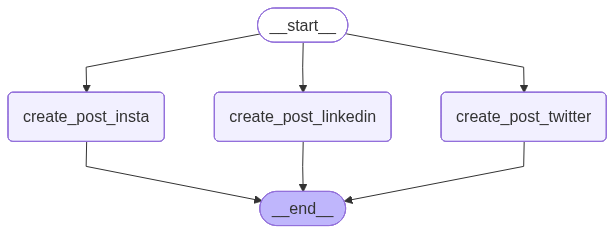

In [33]:
graph = StateGraph(graph_schema)

graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)


graph.add_edge(START, "create_post_insta")
graph.add_edge(START, "create_post_twitter")
graph.add_edge(START, "create_post_linkedin")
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

parallel_graph = graph.compile()




# You could see the errors with the below command
Image(parallel_graph.get_graph().draw_mermaid_png())


In [ ]:
parallel_graph.invoke({"topic": "Artificial Intelligence",
                    "insta": "",
                    "twitter": "",
                    "linkedin": ""})


### **llm pydantic schema**

In [34]:
class llm_schema(BaseModel):
    category: Literal['insta', 'twitter', 'linkedin'] = Field(..., description="Category of the post to generate")
    topic: str = Field(..., description="Topic of the post to generate")


In [35]:
llm_with_schema = llm.with_structured_output(llm_schema)


In [36]:
llm_with_schema.invoke("I want to generate a post for twitter about AI").category


BadRequestError: Error code: 400 - {'code': 400, 'reason': 'INVALID_REQUEST_BODY', 'message': "Model 'qwen/qwen-2.5-72b-instruct' does not support 'json_schema' response format. Supported formats: json_object.", 'metadata': {}}

In [37]:
def decider_node(state: graph_schema) -> graph_schema:

    # Extract the input from the state
    user_input = state['input']

    # Passing the user input to the LLM to decide the category of the post to generate
    response = llm_with_schema.invoke(user_input) # Pydantic Object
    category = response.category # Extracting the category from the Pydantic Object
    topic = response.topic # Extracting the topic from the Pydantic Object

    # Update the state with the decided category and topic
    state['category'] = category
    state['topic'] = topic

    return state


In [38]:
def condition(state: graph_schema) -> str:

    category = state['category']

    if category == 'insta':
        return 'create_insta'
    elif category == 'twitter':
        return 'create_twitter'
    elif category == 'linkedin':
        return 'create_linkedin'
    else:
        raise ValueError("Invalid category")


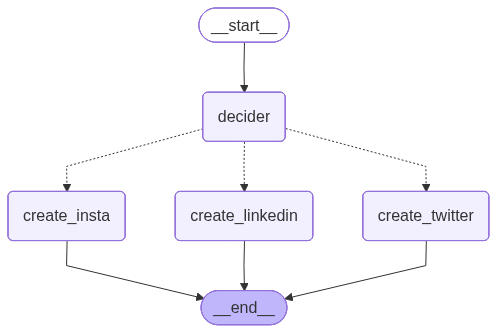

In [39]:
graph = StateGraph(graph_schema)

graph.add_node("decider", decider_node)
graph.add_node("create_insta", create_post_insta)
graph.add_node("create_twitter", create_post_twitter)
graph.add_node("create_linkedin", create_post_linkedin)


graph.add_edge(START, "decider")
graph.add_conditional_edges("decider",condition,{
    'create_insta': "create_insta",
    'create_twitter': "create_twitter",
    'create_linkedin': "create_linkedin"
})

graph.add_edge("create_insta", END)
graph.add_edge("create_twitter", END)
graph.add_edge("create_linkedin", END) 


route_graph = graph.compile()



# You could see the errors with the below command
Image(route_graph.get_graph().draw_mermaid_png())


In [ ]:
route_graph.invoke({
    "input": "I want to generate a post for twitter about AI",
    "topic":"",
    "category":"",
    "post":""
})


### **pydantic llm schema** 

In [40]:
class llm_schema(BaseModel):
    tasks: List[str] = Field(..., description="A list of tasks to be performed by the worker.")

llm_with_schema = llm.with_structured_output(llm_schema)


### **graph schema**

In [41]:
class graph_schema(TypedDict):

    tasks: List[str]
    query: str
    results: List[str]
    summary: str


### **creating orchestrator node**

In [42]:
def orchestrator_node(state: graph_schema) -> graph_schema:

    # Fetching the user query from the state
    user_query = state['query']

    # Create the prompt for the LLM
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are an orchestrator that breaks down a user query into tasks for the worker."),
            ("user", f"User query: {user_query}. Please generate one prompt per task for the worker to complete. Return the tasks in a list format."),
        ]
    )

    # Create the chain
    chain = prompt | llm_with_schema

    # Run the chain with the user query as input
    response = chain.invoke({"query": user_query})


    # Update the state with the generated tasks
    state['tasks'] = response.tasks

    return state


### **worker node**

In [43]:
# Execute Function

def execute(query:str) :

    response = llm.invoke(f"Please execute this task {query}")
    return response.content


In [44]:
def worker_node(state: graph_schema) -> graph_schema:

    tasks = state['tasks']
    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:

        results_futures = executor.map(execute, tasks)
        for result in results_futures:
            results.append(result)
    
    state['results'] = results
    
    return state


### **collector node**

In [45]:
def collector_node(state: graph_schema):

    results = state['results']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes the results from the worker."),
            ("user", f"Here are the results from the worker: {results}. Please summarize these results in a concise manner."),
        ]
    )

    chain = prompt | llm

    summary = chain.invoke({"results": results})

    state['summary'] = summary.content

    return state


### **creating graph and executing**

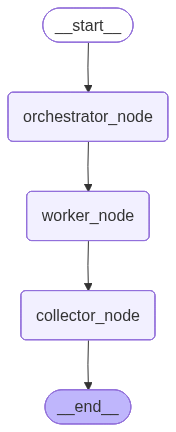

In [46]:
graph = StateGraph(graph_schema)

graph.add_node("orchestrator_node",orchestrator_node)
graph.add_node("worker_node",worker_node)
graph.add_node("collector_node",collector_node)

graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph = graph.compile()


# You could see the errors with the below command
Image(complex_graph.get_graph().draw_mermaid_png())


In [ ]:
complex_graph.invoke(
    {
        "query": "What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?",
        "tasks": [],
        "results": [],
        "summary": "",
    }
)


In [ ]:
for chunk in complex_graph.stream(
    {
        "query": "What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?",
        "tasks": [],
        "results": [],
        "summary": "",
    },
    stream_mode="updates"
):
    print(chunk)


### **pydantic llm schema** 

In [47]:
class llm_schema(BaseModel):
    true_flag: Literal["true","false"] = Field(description="Whether the fact is true or not")
    feedback: str = Field(description="Feedback on the fact")

llm_with_schema = llm.with_structured_output(llm_schema)


### **graph schema**

In [48]:
class graph_schema(TypedDict):

    topic: str
    fact: str
    true_flag: str
    feedback: str
    max_iterations: int


### **nodes**

In [49]:
def generate_node(state: graph_schema) -> graph_schema:
    

    topic = state['topic']

    if state['feedback']: # Not first iteration, generate a fact based on feedback
        response = llm.invoke(f"Please modify the following fact {state['fact']} based on the following feedback: {state['feedback']}") 
    else: # First iteration, generate a fact
        response = llm.invoke("Create only one fact about the following topic: " + topic)

    
    state['fact'] = response.content 
    return state


In [50]:
def evaluate_node(state: graph_schema) -> graph_schema: 

    fact = state['fact']
    iteration = state['max_iterations']

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a fact checker. Your job is to evaluate the following fact and provide feedback on its accuracy."),
        ("user", f"Evaluate the following fact: {fact}\nRespond with 'true' or 'false' and provide feedback if it's false.")
    ])

    chain = prompt | llm_with_schema
    response = chain.invoke({"fact": fact})

    state['true_flag'] = response.true_flag
    state['feedback'] = response.feedback
    state['max_iterations'] = iteration + 1

    return state


### **conditional edge function**

In [51]:
def check_iteration(state: graph_schema) -> str:

    iteration = state['max_iterations']

    if iteration <= 5 and state['true_flag'] != "true":
        return "evaluate_node"
    else:
        return "end"


### **create state graph**

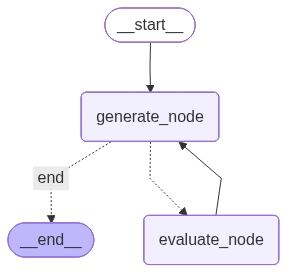

In [52]:
graph = StateGraph(graph_schema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_conditional_edges("generate_node", check_iteration, {"evaluate_node": "evaluate_node", "end": END})
graph.add_edge("evaluate_node", "generate_node")
graph.add_edge("generate_node", END)

evaluator_graph = graph.compile()


# You could see the errors with the below command
Image(evaluator_graph.get_graph().draw_mermaid_png())


### **invoke graph**

In [ ]:
for chunk in evaluator_graph.stream(
    {
        "topic": "AI",
        "fact": "",
        "true_flag": "",
        "feedback": "",
        "max_iterations": 0
    },
    stream_mode="updates"
):
    print(chunk)


### **Human feedback**

[Interrupt(value={'question': 'Approve this action?', 'details': 'Send Daily Summary'}, id='6fa816e5a9e2139ed11fd2fc95ebe2a9')]


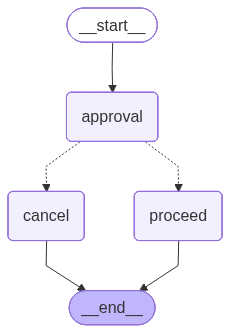

In [56]:
class ApprovalState(TypedDict):
    action_details: str
    status: Optional[Literal["pending", "approved", "rejected"]]


def approval_node(state: ApprovalState) -> Command[Literal["proceed", "cancel"]]:
    # Expose details so the caller can render them in a UI
    decision = interrupt({
        "question": "Approve this action?",
        "details": state["action_details"],
    })

    # Route to the appropriate node after resume
    return Command(goto="proceed" if decision else "cancel")


def proceed_node(state: ApprovalState):
    return {"status": "approved"}


def cancel_node(state: ApprovalState):
    return {"status": "rejected"}


builder = StateGraph(ApprovalState)
builder.add_node("approval", approval_node)
builder.add_node("proceed", proceed_node)
builder.add_node("cancel", cancel_node)
builder.add_edge(START, "approval")
builder.add_edge("proceed", END)
builder.add_edge("cancel", END)

# Use a more durable checkpointer in production
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "approval-456"}}
initial = graph.invoke(
    {"action_details": "Send Daily Summary", "status": "pending"},
    config=config,
)
print(initial["__interrupt__"])  # -> [Interrupt(value={'question': ..., 'details': ...})]

Image(graph.get_graph().draw_mermaid_png())

In [54]:
# Resume with the decision; True routes to proceed, False to cancel
resumed = graph.invoke(Command(resume=False), config=config)
print(resumed["status"])  # -> "rejected"


rejected
